<a href="https://colab.research.google.com/github/M7office/Stroke/blob/main/AHA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Current folder: /content

CSV files found:
 - C_NPX_data.csv
 - C_patient_data.csv
 - NAME_OID.csv
 - strokecog_literature_aligned_pathway_framework.csv
 - strokecog_literature_aligned_protein_pathway_assignment_summary.csv

Generating intermediate pathway-score CSV from raw patient + NPX + pathway-assignment files...
Using raw files:
 - Patient: C_patient_data.csv
 - NPX: C_NPX_data.csv
 - Assignment: strokecog_literature_aligned_protein_pathway_assignment_summary.csv
 - Framework: strokecog_literature_aligned_pathway_framework.csv

Pathway assignment mode: all
Protein-pathway edges used: 1061
Unique proteins mapped: 723
Unique pathways mapped: 12

Low-detection protein filter: complete-case rule
Matched patients: 85
Proteins before filtering: 1196
Proteins removed for missing/below-LOD NPX in >=1 patient: 185
Proteins retained: 1011
Retained protein count matches the reference paper's ML modeling count: 1011.

Generated intermediate CSV from raw data:
 - /content/strokecog_12pathway_

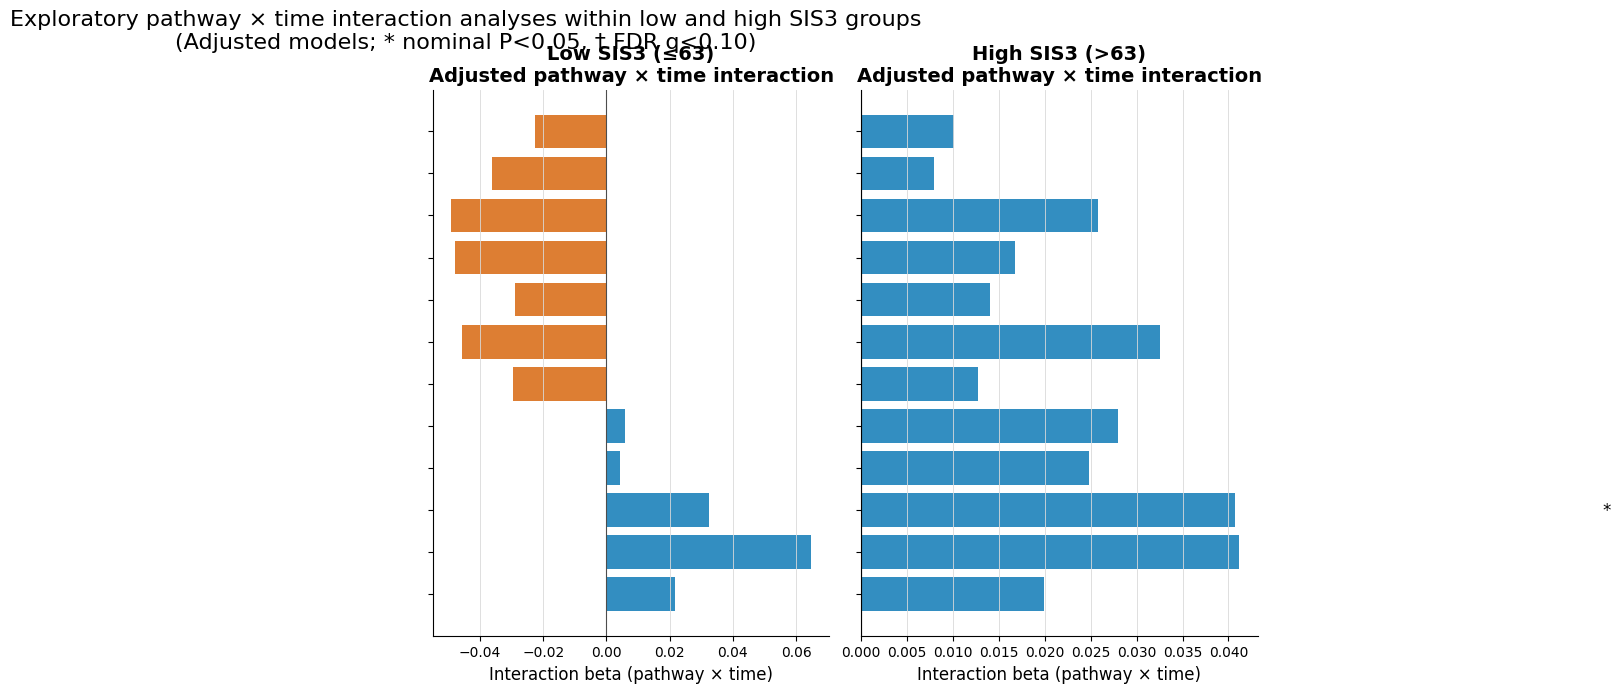

In [30]:
# ============================================================
# StrokeCog v3 figure package — Colab-pasteable version
#
# What this script does:
#   1) Uses the old v3 figure style/figure names.
#   2) Runs from the current Colab folder (/content) — no /mnt/data dependency.
#   3) Generates strokecog_12pathway_scores_for_low_high_heterogeneity.csv
#      from raw patient + NPX + pathway-assignment/framework CSVs.
#   4) If an older intermediate CSV is already present, it backs it up and
#      compares the raw-generated version against the old version.
#   5) Saves slide-ready PNG/PDF/SVG figures + CSV summaries + a ZIP package.
#   6) Uses Li's fixed pathway order and removes visual SEM/error bars from figures.
#   7) Removes low-detection proteins with a complete-case NPX rule before pathway scoring.
#   8) Multi-pathway sensitivity version: one protein can contribute to multiple pathways.
#   9) Excludes Slide 7 and supplementary Slide 3 from generated outputs.
#
# Upload into Colab /content before running:
#   Required option A, intermediate files:
#     - strokecog_12pathway_scores_for_low_high_heterogeneity*.csv
#     - strokecog_low_high_sis3_barplot_values*.csv  (optional but helpful)
#     - strokecog_pathway_time_interaction_within_low_high_sis3_results*.csv (optional)
#
#   Required option B, raw files if intermediate files are missing:
#     - C_patient_data*.csv
#     - C_NPX_data*.csv
#     - strokecog_literature_aligned_pathway_framework*.csv
#     - strokecog_literature_aligned_protein_pathway_assignment_summary*.csv
#     - NAME_OID*.csv (optional)
# ============================================================

from pathlib import Path
import re
import textwrap
import shutil
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from matplotlib.lines import Line2D

warnings.filterwarnings("ignore", category=FutureWarning)

# ============================================================
# 0. Colab folder and output folders
# ============================================================
BASE = Path.cwd()  # Colab default is /content
OUT = BASE / "strokecog_v3_figure_package_multipathway_sensitivity"
FIG = OUT / "figures"
DATA = OUT / "data"

# Clean old output files each run, so Colab does not show stale figures
# from earlier script versions.
CLEAN_OLD_OUTPUTS = True
if CLEAN_OLD_OUTPUTS and OUT.exists():
    shutil.rmtree(OUT)

for p in [OUT, FIG, DATA]:
    p.mkdir(parents=True, exist_ok=True)

SIS3_CUTOFF = 63
TIME_ORDER = ["0–1y", "1–3y", ">3y"]
TIME_BINS = [0, 1, 3, np.inf]
RANDOM_SEED = 42
# Keep pathway display order as 01 at the top through 12 at the bottom.
REVERSE_PATHWAY_DISPLAY_ORDER = False

# Always generate the pathway-score CSV from raw data so the data source is reproducible.
# If an existing intermediate CSV is present, the script backs it up and compares it
# against the regenerated version.
GENERATE_INTERMEDIATE_FROM_RAW = True
COMPARE_TO_EXISTING_INTERMEDIATE = True

# Protein detection filter:
# The reference paper excluded 186 proteins from ML modeling because some samples were
# below the Olink detection limit, leaving 1011 proteins. In our raw CSV, below-LOD values
# are treated as missing/non-numeric. This complete-case rule keeps proteins with numeric
# NPX values for every matched patient.
FILTER_LOW_DETECTION_PROTEINS = True
LOW_DETECTION_FILTER_MODE = "complete_case"  # "complete_case" follows the paper's ML filtering logic

# Sensitivity analysis only:
# Use the all-pathways annotation so one protein can contribute to multiple pathways.
PATHWAY_ASSIGNMENT_MODE = "all"  # options: "primary", "all"

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "axes.titleweight": "bold",
    "figure.titlesize": 16,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.8,
    "savefig.dpi": 400,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

COLORS = {
    "low": "#D55E00",       # orange/vermilion
    "high": "#0072B2",      # blue
    "grey": "#8A8A8A",
    "lightgrey": "#D9D9D9",
    "darkgrey": "#4D4D4D",
    "time1": "#CFE8F3",
    "time2": "#73B3D8",
    "time3": "#1F5A89",
}
TIME_COLORS = {"0–1y": COLORS["time1"], "1–3y": COLORS["time2"], ">3y": COLORS["time3"]}

SHORT = {
    "Serotonin / tryptophan-kynurenine / monoamine metabolism": "Serotonin / kynurenine",
    "Vesicle secretion / extracellular vesicle / membrane trafficking": "Vesicle trafficking",
    "Cell death / cellular stress / proteostasis": "Cell stress",
    "Metabolic / lipid / atherosclerosis / mitochondrial-energy biology": "Metabolic / lipid",
    "mTOR / MAPK / NF-kB / growth-survival signaling": "mTOR / MAPK / NF-kB",
    "Hormone / neuroendocrine / HPA-like systemic signaling": "Hormone / HPA",
    "Systemic organ injury / leakage / comorbidity markers": "Systemic injury / leakage",
    "Peripheral immune / inflammatory activation": "Peripheral immune",
    "Complement / coagulation / platelet axis": "Complement / coagulation",
    "Endothelial / BBB / neurovascular unit": "Endothelial / BBB",
    "Synaptic / neuronal plasticity / neurotrophic signaling": "Synaptic / plasticity",
    "Integrin / ECM / cell adhesion / vascular remodeling": "Integrin / ECM",

}

# Fixed pathway display order requested by Li.
# This is the top-to-bottom order shown in the reference slide.
PATHWAY_ORDER_FIXED = [
    "Serotonin / tryptophan-kynurenine / monoamine metabolism",
    "Vesicle secretion / extracellular vesicle / membrane trafficking",
    "Cell death / cellular stress / proteostasis",
    "Metabolic / lipid / atherosclerosis / mitochondrial-energy biology",
    "mTOR / MAPK / NF-kB / growth-survival signaling",
    "Hormone / neuroendocrine / HPA-like systemic signaling",
    "Systemic organ injury / leakage / comorbidity markers",
    "Peripheral immune / inflammatory activation",
    "Complement / coagulation / platelet axis",
    "Endothelial / BBB / neurovascular unit",
    "Synaptic / neuronal plasticity / neurotrophic signaling",
    "Integrin / ECM / cell adhesion / vascular remodeling",
]

PATHWAY_ORDER_NUMBERED_LABELS = [
    "01. Serotonin / tryptophan-kynurenine / monoamine metabolism",
    "02. Vesicle secretion / extracellular vesicle / membrane trafficking",
    "03. Cell death / cellular stress / proteostasis",
    "04. Metabolic / lipid / atherosclerosis / mitochondrial-energy biology",
    "05. mTOR / MAPK / NF-kB / growth-survival signaling",
    "06. Hormone / neuroendocrine / HPA-like systemic signaling",
    "07. Systemic organ injury / leakage / comorbidity markers",
    "08. Peripheral immune / inflammatory activation",
    "09. Complement / coagulation / platelet axis",
    "10. Endothelial / BBB / neurovascular unit",
    "11. Synaptic / neuronal plasticity / neurotrophic signaling",
    "12. Integrin / ECM / cell adhesion / vascular remodeling",
]

PATHWAY_LABEL_MAP = dict(zip(PATHWAY_ORDER_FIXED, PATHWAY_ORDER_NUMBERED_LABELS))

def numbered_pathway_labels(paths):
    return [PATHWAY_LABEL_MAP.get(p, p) for p in paths]


def wrap_label(s, width=26):
    return "\n".join(textwrap.wrap(str(s), width=width, break_long_words=False))


def read_csv_safely(path: Path) -> pd.DataFrame:
    for enc in ["utf-8", "utf-8-sig", "latin1"]:
        try:
            df = pd.read_csv(path, encoding=enc)
            df.columns = df.columns.astype(str).str.strip()
            return df
        except UnicodeDecodeError:
            continue
    df = pd.read_csv(path)
    df.columns = df.columns.astype(str).str.strip()
    return df


def csv_files():
    return sorted(BASE.glob("*.csv"))


def print_available_csvs():
    print("Current folder:", BASE)
    files = csv_files()
    print("\nCSV files found:")
    for f in files:
        print(" -", f.name)
    return files


def find_csv(contains_all=None, contains_any=None, required=True, label="file", exclude_any=None):
    contains_all = [x.lower() for x in (contains_all or [])]
    contains_any = [x.lower() for x in (contains_any or [])]
    exclude_any = [x.lower() for x in (exclude_any or [])]
    matches = []
    for f in csv_files():
        name = f.name.lower()
        if contains_all and not all(x in name for x in contains_all):
            continue
        if contains_any and not any(x in name for x in contains_any):
            continue
        if exclude_any and any(x in name for x in exclude_any):
            continue
        matches.append(f)
    if not matches:
        if required:
            raise FileNotFoundError(f"Could not find {label}. Tried all={contains_all}, any={contains_any}")
        return None
    # Prefer shortest/cleanest filename if Colab has duplicated (1), (2) copies.
    return sorted(matches, key=lambda p: (len(p.name), p.name))[0]


def normalize_id_value(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    s = re.sub(r"\.0$", "", s)
    return s


def normalize_oid_value(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    m = re.search(r"(OID\d+)", s, flags=re.IGNORECASE)
    if m:
        return m.group(1).upper()
    return s


def normalize_feature_column_name(c):
    s = str(c).strip()
    m = re.search(r"(OID\d+)", s, flags=re.IGNORECASE)
    if m:
        return m.group(1).upper()
    return s


def find_col(df, candidates, required=True, label="column", avoid=None):
    avoid = [a.lower() for a in (avoid or [])]
    cols = df.columns.tolist()
    lower_to_col = {c.lower(): c for c in cols}
    for cand in candidates:
        cand_l = cand.lower()
        if cand_l in lower_to_col:
            c = lower_to_col[cand_l]
            if not any(a in c.lower() for a in avoid):
                return c
    for c in cols:
        c_l = c.lower()
        if any(cand.lower() in c_l for cand in candidates):
            if not any(a in c_l for a in avoid):
                return c
    if required:
        raise ValueError(f"Could not find {label}. Tried {candidates}. Available columns: {cols}")
    return None


def unique_preserve(seq):
    out, seen = [], set()
    for x in seq:
        if pd.isna(x):
            continue
        x = str(x).strip()
        if x and x not in seen:
            out.append(x)
            seen.add(x)
    return out


def detect_time_years(series: pd.Series, colname="") -> pd.Series:
    """Convert a time column to years using conservative heuristics."""
    x = pd.to_numeric(series, errors="coerce")
    lname = str(colname).lower()
    max_val = np.nanmax(x.values) if np.isfinite(x).any() else np.nan
    if "year" in lname or "yrs" in lname or "yr" in lname:
        return x
    if "day" in lname or (np.isfinite(max_val) and max_val > 40):
        return x / 365.25
    if "month" in lname or (np.isfinite(max_val) and max_val > 6):
        return x / 12.0
    # Otherwise assume already in years.
    return x


def zscore_df(df):
    numeric = df.apply(pd.to_numeric, errors="coerce")
    return (numeric - numeric.mean(axis=0)) / numeric.std(axis=0, ddof=0).replace(0, np.nan)


def benjamini_hochberg(pvals):
    pvals = np.asarray(pvals, dtype=float)
    q = np.full_like(pvals, np.nan, dtype=float)
    valid = np.isfinite(pvals)
    p = pvals[valid]
    if len(p) == 0:
        return q
    order = np.argsort(p)
    ranked = p[order]
    m = len(p)
    q_ranked = ranked * m / (np.arange(1, m + 1))
    q_ranked = np.minimum.accumulate(q_ranked[::-1])[::-1]
    q_ranked = np.clip(q_ranked, 0, 1)
    tmp = np.empty_like(q_ranked)
    tmp[order] = q_ranked
    q[valid] = tmp
    return q


def save_figure(fig, stem):
    for ext in ["png", "pdf", "svg"]:
        fig.savefig(FIG / f"{stem}.{ext}", bbox_inches="tight")
    plt.close(fig)


# ============================================================
# 1. Load or create pathway-score table
# ============================================================
print_available_csvs()

pathway_scores_file = find_csv(
    contains_all=["strokecog_12pathway_scores_for_low_high_heterogeneity"],
    required=False,
    label="intermediate pathway-score file",
)

framework_file = find_csv(
    contains_all=["pathway_framework"],
    required=False,
    label="pathway framework file",
)


def load_framework_order():
    if framework_file is None:
        return []
    fw = read_csv_safely(framework_file)
    pathway_col = find_col(fw, ["literature_aligned_pathway", "pathway"], required=False, label="framework pathway column")
    if pathway_col is None:
        return []
    return unique_preserve(fw[pathway_col].dropna().astype(str).str.strip())


framework_order = load_framework_order()


def rebuild_intermediate_from_raw():
    print("\nGenerating intermediate pathway-score CSV from raw patient + NPX + pathway-assignment files...")

    patient_file = find_csv(contains_any=["patient"], required=True, label="patient raw file")
    npx_file = find_csv(contains_any=["npx"], required=True, label="NPX raw file")
    assignment_file = find_csv(contains_all=["protein_pathway_assignment"], required=True, label="protein-pathway assignment file")
    local_framework_order = framework_order
    if not local_framework_order:
        raise FileNotFoundError("Framework file was not found or did not contain a pathway column.")

    print("Using raw files:")
    print(" - Patient:", patient_file.name)
    print(" - NPX:", npx_file.name)
    print(" - Assignment:", assignment_file.name)
    print(" - Framework:", framework_file.name if framework_file else "MISSING")

    patient = read_csv_safely(patient_file)
    npx = read_csv_safely(npx_file)
    assign = read_csv_safely(assignment_file)

    # Detect columns in patient file.
    patient_id_col = find_col(
        patient,
        ["patient_id", "patientid", "participant_id", "subject_id", "sample_id", "record_id", "id"],
        required=False,
        label="patient ID column",
        avoid=["sis", "score", "time", "age"],
    )
    if patient_id_col is None:
        # fallback: column with highest uniqueness, avoiding obvious clinical variables
        candidates = []
        for c in patient.columns:
            if any(k in c.lower() for k in ["sis", "score", "time", "age", "sex", "nihss", "size"]):
                continue
            candidates.append((patient[c].astype(str).nunique(dropna=True), c))
        patient_id_col = sorted(candidates, reverse=True)[0][1]

    sis3_col = find_col(patient, ["sis3", "sis_3", "sis 3", "stroke impact", "score"], label="SIS3 column")
    time_col = find_col(patient, ["time_year", "time_years", "years", "month", "day", "time_since", "time"], required=False, label="time column")

    patient["_patient_id_norm"] = patient[patient_id_col].map(normalize_id_value)
    patient["sis3"] = pd.to_numeric(patient[sis3_col], errors="coerce")
    if time_col is not None:
        patient["time_years"] = detect_time_years(patient[time_col], time_col)
    else:
        raise ValueError("Could not detect a time-since-stroke column in the patient file.")

    # Build NPX wide table.
    ref_ids = set(patient["_patient_id_norm"].dropna().astype(str))
    id_col_npx = None
    best_overlap = -1
    for c in npx.columns:
        vals = set(npx[c].map(normalize_id_value).dropna().astype(str))
        overlap = len(vals.intersection(ref_ids))
        if overlap > best_overlap:
            best_overlap = overlap
            id_col_npx = c
    if best_overlap <= 0:
        raise ValueError("Could not match patient IDs between patient and NPX files.")

    npx_value_col = find_col(npx, ["npx", "value"], required=False, label="NPX value column")
    oid_col_npx = find_col(npx, ["oid", "olinkid", "assay", "protein_id"], required=False, label="OID column in NPX file")
    if npx_value_col is not None and oid_col_npx is not None and id_col_npx != oid_col_npx:
        # long format
        npx["_patient_id_norm"] = npx[id_col_npx].map(normalize_id_value)
        npx["_OID_norm"] = npx[oid_col_npx].map(normalize_oid_value)
        npx_wide = (
            npx.pivot_table(index="_patient_id_norm", columns="_OID_norm", values=npx_value_col, aggfunc="mean")
            .reset_index()
        )
    else:
        # wide format
        npx_wide = npx.copy()
        npx_wide["_patient_id_norm"] = npx_wide[id_col_npx].map(normalize_id_value)
        rename = {c: normalize_feature_column_name(c) for c in npx_wide.columns}
        npx_wide = npx_wide.rename(columns=rename)

    # Protein-pathway mapping.
    oid_col_assign = find_col(assign, ["OID", "oid", "olinkid", "protein_id"], label="OID column in assignment file")

    if PATHWAY_ASSIGNMENT_MODE == "primary":
        pathway_col_assign = find_col(
            assign,
            ["primary_literature_aligned_pathway_draft", "primary_literature_aligned_pathway", "pathway"],
            label="primary pathway column in assignment file",
        )
        mapping = assign[[oid_col_assign, pathway_col_assign]].copy()
        mapping.columns = ["OID", "pathway"]

    elif PATHWAY_ASSIGNMENT_MODE == "all":
        pathway_col_assign = find_col(
            assign,
            ["all_literature_aligned_pathways_draft", "all_literature_aligned_pathways", "all_pathways", "pathways"],
            label="all-pathways column in assignment file",
        )
        mapping = assign[[oid_col_assign, pathway_col_assign]].copy()
        mapping.columns = ["OID", "pathway"]
        # Split multiple pathways. Supports semicolon, pipe, or comma-separated labels.
        mapping["pathway"] = mapping["pathway"].astype(str).str.split(r"\s*[;|,]\s*", regex=True)
        mapping = mapping.explode("pathway")

    else:
        raise ValueError("PATHWAY_ASSIGNMENT_MODE must be 'primary' or 'all'.")

    mapping["OID"] = mapping["OID"].map(normalize_oid_value)
    mapping["pathway"] = mapping["pathway"].astype(str).str.strip()
    mapping = mapping.dropna()
    mapping = mapping[mapping["pathway"].isin(local_framework_order)]

    # Save the exact protein-pathway edges used for this sensitivity analysis.
    mapping.to_csv(DATA / "protein_pathway_mapping_edges_used.csv", index=False)
    print("\nPathway assignment mode:", PATHWAY_ASSIGNMENT_MODE)
    print("Protein-pathway edges used:", len(mapping))
    print("Unique proteins mapped:", mapping["OID"].nunique())
    print("Unique pathways mapped:", mapping["pathway"].nunique())

    # Merge patient + NPX.
    merged = patient.merge(npx_wide, on="_patient_id_norm", how="inner")
    if merged.empty:
        raise ValueError("Patient and NPX files did not merge after ID normalization.")

    protein_cols = [c for c in merged.columns if re.fullmatch(r"OID\d+", str(c), flags=re.IGNORECASE)]
    protein_cols = [normalize_feature_column_name(c) for c in protein_cols]
    # If duplicate names occurred after normalization, keep first by grouping columns.
    merged = merged.loc[:, ~merged.columns.duplicated()].copy()
    protein_cols = [c for c in protein_cols if c in merged.columns]

    mapping = mapping[mapping["OID"].isin(protein_cols)].copy()
    if mapping.empty:
        raise ValueError("No pathway-assignment OIDs matched NPX protein columns.")

    # Low-detection filtering, aligned with the reference paper's ML modeling logic.
    # Below-LOD / non-numeric values become NaN. With complete_case filtering, any protein
    # with at least one missing/below-LOD value across the matched patients is removed.
    protein_numeric = merged[protein_cols].apply(pd.to_numeric, errors="coerce")
    detected_count = protein_numeric.notna().sum(axis=0)
    detection_rate = detected_count / len(protein_numeric)

    detection_qc = pd.DataFrame({
        "OID": protein_numeric.columns,
        "n_detected_numeric": detected_count.values,
        "n_patients": len(protein_numeric),
        "detection_rate": detection_rate.values,
        "removed_low_detection": detection_rate.values < 1.0,
    })
    detection_qc.to_csv(DATA / "protein_detection_filter_qc.csv", index=False)

    if FILTER_LOW_DETECTION_PROTEINS and LOW_DETECTION_FILTER_MODE == "complete_case":
        retained_protein_cols = detection_rate[detection_rate == 1.0].index.tolist()
        removed_protein_cols = detection_rate[detection_rate < 1.0].index.tolist()
        print("\nLow-detection protein filter: complete-case rule")
        print(f"Matched patients: {len(protein_numeric)}")
        print(f"Proteins before filtering: {len(protein_cols)}")
        print(f"Proteins removed for missing/below-LOD NPX in >=1 patient: {len(removed_protein_cols)}")
        print(f"Proteins retained: {len(retained_protein_cols)}")
        if len(retained_protein_cols) == 1011:
            print("Retained protein count matches the reference paper's ML modeling count: 1011.")
        else:
            print("Note: retained count is not 1011. This can happen if the uploaded raw NPX file has already been filtered, has different missing-value encoding, or differs from the paper source table.")
        protein_cols = retained_protein_cols
        mapping = mapping[mapping["OID"].isin(protein_cols)].copy()
        protein_numeric = protein_numeric[protein_cols]
    else:
        print("\nLow-detection protein filter is OFF. Using all numeric protein columns with NaN-skipping.")

    if mapping.empty:
        raise ValueError("No pathway-assignment OIDs remained after low-detection filtering.")

    protein_z = zscore_df(protein_numeric)

    # Pathway mapping mode:
    # This script uses PRIMARY pathway assignment only. It does not duplicate a protein across
    # multiple pathways unless we explicitly change the mapping column to an all-pathways field.
    score_df = merged[["_patient_id_norm", "sis3", "time_years"]].copy()
    for p in local_framework_order:
        oids = sorted(set(mapping.loc[mapping["pathway"] == p, "OID"]).intersection(protein_z.columns))
        if len(oids) == 0:
            score_df[p] = np.nan
        else:
            score_df[p] = protein_z[oids].mean(axis=1)

    # Save intermediate files expected by the old v3 plotting code.
    pathway_score_out = BASE / "strokecog_12pathway_scores_for_low_high_heterogeneity_multipathway_sensitivity.csv"
    scatter_out = BASE / "strokecog_low_high_sis3_scatter_side_by_side_summary_multipathway_sensitivity.csv"
    score_df.to_csv(pathway_score_out, index=False)
    score_df.to_csv(scatter_out, index=False)

    # Also save a copy inside the output data folder.
    score_df.to_csv(DATA / "raw_generated_strokecog_12pathway_scores_for_low_high_heterogeneity_multipathway_sensitivity.csv", index=False)

    print("\nGenerated intermediate CSV from raw data:")
    print(" -", pathway_score_out)
    print(" -", scatter_out)
    print("Shape of pathway-score table:", score_df.shape)

    # Bar value table in long format.
    rows = []
    score_df["sis3_level"] = np.where(score_df["sis3"] <= SIS3_CUTOFF, "Low SIS3 (≤63)", "High SIS3 (>63)")
    for group in ["Low SIS3 (≤63)", "High SIS3 (>63)"]:
        sub = score_df[score_df["sis3_level"] == group]
        for p in local_framework_order:
            vals = pd.to_numeric(sub[p], errors="coerce").dropna().values
            rows.append({
                "sis3_level": group,
                "pathway": p,
                "mean": np.mean(vals) if len(vals) else np.nan,
                "sd": np.std(vals, ddof=1) if len(vals) > 1 else np.nan,
                "sem": np.std(vals, ddof=1) / np.sqrt(len(vals)) if len(vals) > 1 else np.nan,
                "n": len(vals),
            })
    pd.DataFrame(rows).to_csv(BASE / "strokecog_low_high_sis3_barplot_values.csv", index=False)

    # Exploratory time-slope table used only for the supplementary slide-3 panel.
    int_rows = []
    try:
        from scipy import stats as scipy_stats
        for group in ["Low SIS3 (≤63)", "High SIS3 (>63)"]:
            sub = score_df[score_df["sis3_level"] == group].copy()
            for p in local_framework_order:
                dat = sub[["time_years", p]].dropna()
                if len(dat) >= 4 and dat["time_years"].nunique() >= 2:
                    res = scipy_stats.linregress(dat["time_years"], dat[p])
                    beta = res.slope
                    se = res.stderr if res.stderr is not None else np.nan
                    ci_low = beta - 1.96 * se if np.isfinite(se) else np.nan
                    ci_high = beta + 1.96 * se if np.isfinite(se) else np.nan
                    pval = res.pvalue
                else:
                    beta = ci_low = ci_high = pval = np.nan
                int_rows.append({
                    "sis3_group": group.replace("(", "").replace(")", ""),
                    "model": "Adjusted",
                    "pathway": p,
                    "beta_interaction": beta,
                    "ci_low": ci_low,
                    "ci_high": ci_high,
                    "p_value": pval,
                })
        int_df = pd.DataFrame(int_rows)
        int_df["fdr_q"] = benjamini_hochberg(int_df["p_value"].values)
        int_df.to_csv(BASE / "strokecog_pathway_time_interaction_within_low_high_sis3_results.csv", index=False)
    except Exception as e:
        print("Could not create exploratory time-interaction table; supplementary test figure will be skipped.")
        print("Reason:", e)

    # Save a small audit file so you can check exactly how the CSV was generated.
    audit_path = DATA / "intermediate_csv_generation_audit.txt"
    with open(audit_path, "w", encoding="utf-8") as f:
        f.write("Intermediate pathway-score CSV generation audit\n")
        f.write("=============================================\n\n")
        f.write(f"Patient file: {patient_file.name}\n")
        f.write(f"NPX file: {npx_file.name}\n")
        f.write(f"Assignment file: {assignment_file.name}\n")
        f.write(f"Framework file: {framework_file.name if framework_file else 'MISSING'}\n")
        f.write(f"Patient ID column: {patient_id_col}\n")
        f.write(f"SIS3 column: {sis3_col}\n")
        f.write(f"Time column: {time_col}\n")
        f.write(f"NPX ID column: {id_col_npx}\n")
        f.write(f"Number of merged patients: {merged['_patient_id_norm'].nunique()}\n")
        f.write(f"Low-detection filtering enabled: {FILTER_LOW_DETECTION_PROTEINS}\n")
        f.write(f"Low-detection filtering mode: {LOW_DETECTION_FILTER_MODE}\n")
        f.write(f"Number of protein columns retained after filtering: {len(protein_cols)}\n")
        f.write(f"Number of pathway assignments used after filtering: {len(mapping)}\n")
        f.write(f"Output pathway score table shape: {score_df.shape}\n")
    print("Audit file saved:", audit_path)

    print("Generated and saved intermediate CSVs in", BASE)
    return score_df.copy()


def compare_existing_vs_raw_generated(existing_df, raw_df, pathway_cols, out_prefix="intermediate_raw_vs_existing"):
    """Compare old intermediate CSV against the raw-generated intermediate CSV."""
    existing = existing_df.copy()
    raw = raw_df.copy()
    existing.columns = existing.columns.astype(str).str.strip()
    raw.columns = raw.columns.astype(str).str.strip()

    key = None
    for candidate in ["_patient_id_norm", "patient_id", "participant_id", "subject_id", "sample_id", "id"]:
        if candidate in existing.columns and candidate in raw.columns:
            key = candidate
            break

    if key is not None:
        existing[key] = existing[key].map(normalize_id_value)
        raw[key] = raw[key].map(normalize_id_value)
        merged_cmp = existing.merge(raw, on=key, how="outer", suffixes=("_existing", "_raw"), indicator=True)
        alignment_note = f"aligned by {key}"
    else:
        existing["_row_order"] = np.arange(len(existing))
        raw["_row_order"] = np.arange(len(raw))
        key = "_row_order"
        merged_cmp = existing.merge(raw, on=key, how="outer", suffixes=("_existing", "_raw"), indicator=True)
        alignment_note = "aligned by row order because no shared patient ID column was found"

    rows = []
    for col in pathway_cols:
        ex_col = f"{col}_existing"
        raw_col = f"{col}_raw"
        if ex_col not in merged_cmp.columns or raw_col not in merged_cmp.columns:
            continue
        ex = pd.to_numeric(merged_cmp[ex_col], errors="coerce")
        rw = pd.to_numeric(merged_cmp[raw_col], errors="coerce")
        diff = rw - ex
        diff_abs = np.abs(diff)
        rows.append({
            "pathway": col,
            "n_compared": int((ex.notna() & rw.notna()).sum()),
            "max_abs_diff": float(np.nanmax(diff_abs)) if np.isfinite(np.nanmax(diff_abs)) else np.nan,
            "mean_abs_diff": float(np.nanmean(diff_abs)) if np.isfinite(np.nanmean(diff_abs)) else np.nan,
        })

    summary = pd.DataFrame(rows)
    summary_path = DATA / f"{out_prefix}_summary.csv"
    detail_path = DATA / f"{out_prefix}_patient_level_table.csv"
    readme_path = DATA / f"{out_prefix}_README.txt"

    summary.to_csv(summary_path, index=False)
    merged_cmp.to_csv(detail_path, index=False)

    overall_max = summary["max_abs_diff"].max() if not summary.empty else np.nan
    n_left_only = int((merged_cmp["_merge"] == "left_only").sum()) if "_merge" in merged_cmp.columns else 0
    n_right_only = int((merged_cmp["_merge"] == "right_only").sum()) if "_merge" in merged_cmp.columns else 0

    with open(readme_path, "w", encoding="utf-8") as f:
        f.write("Raw-generated vs existing intermediate CSV comparison\n")
        f.write("====================================================\n\n")
        f.write(f"Alignment: {alignment_note}\n")
        f.write(f"Existing rows only: {n_left_only}\n")
        f.write(f"Raw-generated rows only: {n_right_only}\n")
        f.write(f"Overall max absolute pathway-score difference: {overall_max}\n\n")
        f.write("If overall max absolute difference is 0 or very close to 0, the raw data generation reproduces the existing intermediate CSV.\n")
        f.write("If it is not close to 0, check the summary and patient-level comparison CSVs.\n")

    print("\nRaw-generated vs existing intermediate CSV comparison:")
    print("Alignment:", alignment_note)
    print("Existing rows only:", n_left_only)
    print("Raw-generated rows only:", n_right_only)
    print("Overall max absolute pathway-score difference:", overall_max)
    print("Comparison files saved:")
    print(" -", summary_path)
    print(" -", detail_path)
    print(" -", readme_path)

    return summary



existing_intermediate_df = None
if pathway_scores_file is not None and COMPARE_TO_EXISTING_INTERMEDIATE:
    print("\nExisting intermediate CSV found. It will be backed up and compared against raw-generated data:")
    print(" -", pathway_scores_file.name)
    existing_intermediate_df = read_csv_safely(pathway_scores_file)
    existing_intermediate_df.to_csv(DATA / "existing_intermediate_before_raw_regeneration.csv", index=False)

if GENERATE_INTERMEDIATE_FROM_RAW:
    DATA_SOURCE_FOR_PATHWAY_SCORES = "generated from raw patient + NPX + all-pathways assignment file; multi-pathway sensitivity"
    pathway_df = rebuild_intermediate_from_raw()
else:
    if pathway_scores_file is None:
        DATA_SOURCE_FOR_PATHWAY_SCORES = "intermediate CSV missing; generated from raw patient + NPX + pathway-assignment files"
        pathway_df = rebuild_intermediate_from_raw()
    else:
        DATA_SOURCE_FOR_PATHWAY_SCORES = f"existing intermediate CSV: {pathway_scores_file.name}"
        print("\nUsing existing pathway-score file:", pathway_scores_file.name)
        pathway_df = read_csv_safely(pathway_scores_file)

print("\nPathway-score data source used for figures:", DATA_SOURCE_FOR_PATHWAY_SCORES)
print("Intermediate pathway-score CSV available at:")
print(BASE / "strokecog_12pathway_scores_for_low_high_heterogeneity.csv")

# ============================================================
# 2. Standardize pathway table shape: long or wide -> wide
# ============================================================
pathway_df.columns = pathway_df.columns.astype(str).str.strip()

# If the score file is long, pivot it to the wide format expected by the old figures.
if "pathway" in pathway_df.columns and any(c in pathway_df.columns for c in ["pathway_score", "mean_pathway_score"]):
    score_col = "pathway_score" if "pathway_score" in pathway_df.columns else "mean_pathway_score"
    sis_col = find_col(pathway_df, ["sis3", "SIS3", "score"], required=True, label="SIS3 column")
    time_col = find_col(pathway_df, ["time_years", "time_since_stroke", "time"], required=False, label="time column")
    id_col = find_col(pathway_df, ["_patient_id_norm", "patient_id", "participant_id", "subject_id", "sample_id", "id"], required=False, label="patient ID")
    if id_col is None:
        pathway_df["_row_id"] = np.arange(len(pathway_df))
        id_col = "_row_id"
    index_cols = [id_col, sis_col]
    if time_col is not None:
        index_cols.append(time_col)
    wide = pathway_df.pivot_table(index=index_cols, columns="pathway", values=score_col, aggfunc="mean").reset_index()
    pathway_df = wide.rename(columns={sis_col: "sis3"})
    if time_col is not None:
        pathway_df = pathway_df.rename(columns={time_col: "time_years_raw"})
        pathway_df["time_years"] = detect_time_years(pathway_df["time_years_raw"], time_col)
else:
    # Already wide.
    sis_col = find_col(pathway_df, ["sis3", "SIS3", "score"], required=True, label="SIS3 column")
    if sis_col != "sis3":
        pathway_df = pathway_df.rename(columns={sis_col: "sis3"})
    time_col = find_col(pathway_df, ["time_years", "time_since_stroke_years", "time_since_stroke", "years", "months", "days", "time"], required=False, label="time column")
    if time_col is not None and time_col != "time_years":
        pathway_df["time_years"] = detect_time_years(pathway_df[time_col], time_col)
    elif time_col == "time_years":
        pathway_df["time_years"] = pd.to_numeric(pathway_df["time_years"], errors="coerce")
    else:
        raise ValueError("Could not detect time_years / time-since-stroke column.")

pathway_df["sis3"] = pd.to_numeric(pathway_df["sis3"], errors="coerce")
pathway_df["time_years"] = pd.to_numeric(pathway_df["time_years"], errors="coerce")
pathway_df["sis3_level"] = np.where(pathway_df["sis3"] <= SIS3_CUTOFF, "Low SIS3 (≤63)", "High SIS3 (>63)")
pathway_df["time_bin"] = pd.cut(pathway_df["time_years"], bins=TIME_BINS, labels=TIME_ORDER, include_lowest=True)

# Determine pathway order.
# Use the fixed top-to-bottom order requested for the deck.
barvals_file = find_csv(contains_all=["strokecog_low_high_sis3_barplot_values"], required=False, label="barplot values file")
barvals = read_csv_safely(barvals_file) if barvals_file is not None else pd.DataFrame()

pathway_order = [p for p in PATHWAY_ORDER_FIXED if p in pathway_df.columns]

# Safety fallback: if names differ slightly, keep any remaining numeric pathway columns after the fixed list.
meta = {"sis3", "time_years", "time_years_raw", "time_bin", "sis3_level", "sis3_group"}
meta.update([c for c in pathway_df.columns if any(k in c.lower() for k in ["patient", "subject", "sample", "id", "age", "sex", "nihss", "stroke_size"])])
remaining_numeric_pathways = [
    c for c in pathway_df.columns
    if c not in meta and c not in pathway_order and pd.api.types.is_numeric_dtype(pathway_df[c])
]
if len(pathway_order) < len(PATHWAY_ORDER_FIXED):
    missing_fixed = [p for p in PATHWAY_ORDER_FIXED if p not in pathway_df.columns]
    print("\nWarning: these fixed-order pathways were not found as columns and will be skipped:")
    for p in missing_fixed:
        print(" -", p)

# Do not use extra pathways in the main plots unless none of the fixed-order pathways are found.
if len(pathway_order) == 0:
    print("\nNo exact matches to PATHWAY_ORDER_FIXED were found. Falling back to numeric pathway columns.")
    pathway_order = remaining_numeric_pathways

if len(pathway_order) == 0:
    raise ValueError("Could not determine pathway columns. Check the pathway score file structure.")

if REVERSE_PATHWAY_DISPLAY_ORDER:
    pathway_order = list(reversed(pathway_order))

print("\nPathways used in plotting order:")
for i, p in enumerate(pathway_order, 1):
    print(f"{i:02d}. {p}")

# Compare raw-generated intermediate to the existing intermediate CSV, if one was present.
if existing_intermediate_df is not None:
    compare_existing_vs_raw_generated(existing_intermediate_df, pathway_df, pathway_order)

# Save standardized table.
pathway_df.to_csv(DATA / "standardized_wide_pathway_scores_used_for_figures.csv", index=False)

# ============================================================
# 3. Summary tables for plotting
# ============================================================
rows = []
for group in ["Low SIS3 (≤63)", "High SIS3 (>63)"]:
    sub = pathway_df[pathway_df["sis3_level"] == group]
    for p in pathway_order:
        vals = pd.to_numeric(sub[p], errors="coerce").dropna().values
        rows.append({
            "sis3_level": group,
            "pathway": p,
            "mean": np.mean(vals) if len(vals) else np.nan,
            "sd": np.std(vals, ddof=1) if len(vals) > 1 else np.nan,
            "sem": np.std(vals, ddof=1) / np.sqrt(len(vals)) if len(vals) > 1 else np.nan,
            "n": len(vals),
        })
mean_df = pd.DataFrame(rows)
mean_df.to_csv(DATA / "slide2_low_high_pathway_means_ordered.csv", index=False)

rows = []
for group in ["Low SIS3 (≤63)", "High SIS3 (>63)"]:
    for t in TIME_ORDER:
        sub = pathway_df[(pathway_df["sis3_level"] == group) & (pathway_df["time_bin"].astype(str) == t)]
        for p in pathway_order:
            vals = pd.to_numeric(sub[p], errors="coerce").dropna().values
            rows.append({
                "sis3_level": group,
                "time_bin": t,
                "pathway": p,
                "mean": np.mean(vals) if len(vals) else np.nan,
                "sd": np.std(vals, ddof=1) if len(vals) > 1 else np.nan,
                "sem": np.std(vals, ddof=1) / np.sqrt(len(vals)) if len(vals) > 1 else np.nan,
                "n": len(vals),
            })
subgroup_df = pd.DataFrame(rows)
subgroup_df.to_csv(DATA / "slide3_low_high_timebin_pathway_means.csv", index=False)
subgroup_df.to_csv(DATA / "slide3_time_stage_pathway_means_used_for_plot.csv", index=False)

# Data QC for Slide 3: this is the patient count table used to annotate n in each panel.
slide3_patient_counts = (
    pathway_df
    .groupby(["sis3_level", "time_bin"], observed=True)
    .size()
    .reset_index(name="n_patients")
)
slide3_patient_counts.to_csv(DATA / "slide3_patient_counts_by_sis3_group_and_time_bin.csv", index=False)

with open(DATA / "slide3_data_QC_README.txt", "w", encoding="utf-8") as f:
    f.write("Slide 3 data QC\n")
    f.write("================\n\n")
    f.write(f"Pathway-score data source: {DATA_SOURCE_FOR_PATHWAY_SCORES}\n")
    f.write(f"SIS3 cutoff: <= {SIS3_CUTOFF} = Low SIS3; > {SIS3_CUTOFF} = High SIS3\n")
    f.write("Time bins: 0-1y, 1-3y, >3y\n\n")
    f.write("The plotted bar lengths are the mean pathway scores in:\n")
    f.write("  slide3_time_stage_pathway_means_used_for_plot.csv\n\n")
    f.write("The n values in panel titles are saved in:\n")
    f.write("  slide3_patient_counts_by_sis3_group_and_time_bin.csv\n")

print("\nSlide 3 patient counts used for panel titles:")
print(slide3_patient_counts.to_string(index=False))
print("\nSlide 3 pathway means used for bars saved to:")
print(DATA / "slide3_time_stage_pathway_means_used_for_plot.csv")

# Dynamic x limits used across bar/profile figures.
all_means = pd.to_numeric(subgroup_df["mean"], errors="coerce").dropna().values
lim = max(0.25, np.nanmax(np.abs(all_means)) * 1.25) if len(all_means) else 0.5

# ============================================================
# 4. Slide 2 — distinct pathway configurations
# ============================================================
fig, ax = plt.subplots(figsize=(10.8, 6.8))
y = np.arange(len(pathway_order))
width = 0.36
low_sub = mean_df[mean_df["sis3_level"] == "Low SIS3 (≤63)"].set_index("pathway").reindex(pathway_order).reset_index()
high_sub = mean_df[mean_df["sis3_level"] == "High SIS3 (>63)"].set_index("pathway").reindex(pathway_order).reset_index()
ax.barh(y - width / 2, low_sub["mean"], height=width, color=COLORS["low"], label="Low SIS3 (≤63)")
ax.barh(y + width / 2, high_sub["mean"], height=width, color=COLORS["high"], label="High SIS3 (>63)")
ax.axvline(0, color=COLORS["darkgrey"], lw=0.8)
ax.set_xlim(-lim, lim)
ax.set_yticks(y)
ax.set_yticklabels(numbered_pathway_labels(pathway_order))
ax.invert_yaxis()
ax.set_xlabel("Mean pathway score (z)")
ax.set_title("Distinct coordinated pathway configurations in low versus high SIS3")
ax.legend(frameon=False, loc="lower right")
ax.grid(axis="x", color=COLORS["lightgrey"], lw=0.6)
fig.subplots_adjust(left=0.53, right=0.98, bottom=0.10, top=0.92)
save_figure(fig, "slide2_distinct_pathway_configurations")

# ============================================================
# 5. Slide 5 support — SIS3 score distribution across time-since-stroke bins
# Requested version: two panels, Low SIS3 only vs High SIS3 only
# ============================================================
df = pathway_df.copy()
df["time_bin"] = pd.Categorical(df["time_bin"].astype(str), categories=TIME_ORDER, ordered=True)

fig, axes = plt.subplots(1, 2, figsize=(12.0, 5.5), sharey=True)
group_specs = [
    ("Low SIS3 (≤63)", "Low SIS3 only"),
    ("High SIS3 (>63)", "High SIS3 only"),
]

# soft violin fill shared across both panels, colored points by time bin
violin_fill = "#A9C4D8"
point_colors = {"0–1y": "#2C7FB8", "1–3y": "#F28E2B", ">3y": "#2CA25F"}
summary_line_color = "#D94841"
iqr_line_color = "#CC79A7"

for ax, (grp, panel_title) in zip(axes, group_specs):
    grp_df = df[df["sis3_level"] == grp].copy()
    groups_data = [grp_df.loc[grp_df["time_bin"].astype(str) == t, "sis3"].dropna().values for t in TIME_ORDER]

    positions = np.arange(1, len(TIME_ORDER) + 1)
    parts = ax.violinplot(groups_data, positions=positions, showmeans=False, showmedians=False, widths=0.75)

    for pc in parts["bodies"]:
        pc.set_facecolor(violin_fill)
        pc.set_edgecolor("none")
        pc.set_alpha(0.85)
    for k in ["cbars", "cmins", "cmaxes"]:
        if k in parts:
            parts[k].set_color("none")

    for i, t in enumerate(TIME_ORDER, start=1):
        vals = grp_df.loc[grp_df["time_bin"].astype(str) == t, "sis3"].dropna().values
        if len(vals) == 0:
            continue

        x = i + rng.uniform(-0.08, 0.08, size=len(vals))
        ax.scatter(
            x, vals, s=34, color=point_colors[t], alpha=0.9,
            edgecolor="none", zorder=3
        )

        mean_val = np.mean(vals)
        q1 = np.percentile(vals, 25)
        q3 = np.percentile(vals, 75)
        ax.hlines(mean_val, i - 0.23, i + 0.23, color=summary_line_color, lw=2.0, zorder=4)
        ax.vlines(i, q1, q3, color=iqr_line_color, lw=1.8, zorder=4)

        y_text = min(max(vals) + 2.5, 102)
        ax.text(i, y_text, f"n={len(vals)}", ha="center", va="bottom", fontsize=11)

    ax.axhline(SIS3_CUTOFF, color=COLORS["high"], lw=1.5, ls="--")
    ax.set_xticks(positions)
    ax.set_xticklabels(TIME_ORDER)
    ax.set_xlabel("Time since stroke")
    ax.set_title(panel_title, pad=4)
    ax.grid(axis="y", color=COLORS["lightgrey"], lw=0.6)
    ax.set_ylim(0, 105)

axes[0].set_ylabel("SIS3 score")
axes[1].text(3.25, SIS3_CUTOFF + 1.2, f"SIS3 = {SIS3_CUTOFF}", color=COLORS["darkgrey"], fontsize=10, va="center")

fig.suptitle("SIS3 score distribution across time-since-stroke bins: Low vs High SIS3", y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
save_figure(fig, "slide5_sis3_distribution_low_vs_high")


# Slide 3 figures — time-stage pathway profiles with NO SEM/error bars
# Generate separate figures for low-SIS3 and high-SIS3 groups, with numbered pathway labels
# shown on the left subplot only. Important: do NOT blank y tick labels on shared axes using
# set_yticklabels([]), because that propagates across shared axes in matplotlib.
for split_group, split_stem in [
    ("Low SIS3 (≤63)", "slide3_low_sis3_time_stage_pathway_profiles"),
    ("High SIS3 (>63)", "slide3_high_sis3_time_stage_pathway_profiles"),
]:
    fig, axes = plt.subplots(1, 3, figsize=(24.0, 7.2), sharex=True, sharey=True)
    color = COLORS["low"] if "Low" in split_group else COLORS["high"]

    for j, (ax, t) in enumerate(zip(axes, TIME_ORDER)):
        sub = (
            subgroup_df[(subgroup_df["sis3_level"] == split_group) & (subgroup_df["time_bin"] == t)]
            .set_index("pathway")
            .reindex(pathway_order)
            .reset_index()
        )
        yy = np.arange(len(pathway_order))
        ax.barh(yy, sub["mean"], color=color, alpha=0.95)
        ax.axvline(0, color=COLORS["darkgrey"], lw=0.8)
        ax.grid(axis="x", color=COLORS["lightgrey"], lw=0.6)
        ax.set_xlim(-lim, lim)

        n_panel = int(np.nanmax(sub["n"].values)) if sub["n"].notna().any() else 0
        short_grp = split_group.replace(" (≤63)", " ≤63").replace(" (>63)", " >63")
        ax.set_title(f"{t}\n{short_grp} (n={n_panel})", fontsize=11)
        ax.set_xlabel("Mean pathway score")
        ax.set_yticks(yy)
        ax.invert_yaxis()

    # Apply y-axis labels only after all shared axes have been created.
    axes[0].set_yticks(np.arange(len(pathway_order)))
    axes[0].set_yticklabels(numbered_pathway_labels(pathway_order))
    axes[0].tick_params(axis="y", labelleft=True, labelsize=8, pad=4)
    for lbl in axes[0].get_yticklabels():
        lbl.set_horizontalalignment("right")
    axes[0].set_ylabel("Pathway")

    # Hide duplicate y tick labels on the other two shared panels without overwriting the shared labels.
    for ax in axes[1:]:
        ax.tick_params(axis="y", labelleft=False)

    fig.subplots_adjust(left=0.58, right=0.985, bottom=0.12, top=0.90, wspace=0.06)
    save_figure(fig, split_stem)

# Supplementary pathway × time test figure, if the interaction file exists.
interaction_file = find_csv(contains_all=["pathway_time_interaction"], required=False, label="pathway-time interaction file")
if interaction_file is not None:
    try:
        interaction_df = read_csv_safely(interaction_file)
        needed = {"pathway", "model", "beta_interaction", "ci_low", "ci_high", "p_value"}
        if needed.issubset(set(interaction_df.columns)):
            int_df = interaction_df.copy()
            if "sis3_group" in int_df.columns:
                int_df["group_label"] = int_df["sis3_group"].astype(str)
                int_df["group_label"] = int_df["group_label"].replace({
                    "Low SIS3 ≤63": "Low SIS3 (≤63)",
                    "High SIS3 >63": "High SIS3 (>63)",
                    "Low SIS3 ≤63": "Low SIS3 (≤63)",
                    "High SIS3 ≥63": "High SIS3 (>63)",
                })
                int_df.loc[int_df["group_label"].str.contains("Low", case=False, na=False), "group_label"] = "Low SIS3 (≤63)"
                int_df.loc[int_df["group_label"].str.contains("High", case=False, na=False), "group_label"] = "High SIS3 (>63)"
            else:
                int_df["group_label"] = "Low SIS3 (≤63)"
            if "fdr_q" not in int_df.columns:
                int_df["fdr_q"] = benjamini_hochberg(int_df["p_value"].values)

            fig, axes = plt.subplots(1, 2, figsize=(16.5, 7), sharey=True)
            for ax, grp in zip(axes, ["Low SIS3 (≤63)", "High SIS3 (>63)"]):
                sub = int_df[(int_df["group_label"] == grp) & (int_df["model"].astype(str).str.lower() == "adjusted")]
                if sub.empty:
                    sub = int_df[int_df["group_label"] == grp]
                plot_sub = sub.set_index("pathway").reindex(pathway_order).reset_index()
                yy = np.arange(len(pathway_order))
                betas = pd.to_numeric(plot_sub["beta_interaction"], errors="coerce").values
                ci_low = pd.to_numeric(plot_sub["ci_low"], errors="coerce").values
                ci_high = pd.to_numeric(plot_sub["ci_high"], errors="coerce").values
                xerr_low = np.where(np.isfinite(betas - ci_low), betas - ci_low, 0)
                xerr_high = np.where(np.isfinite(ci_high - betas), ci_high - betas, 0)
                ax.barh(yy, betas, color=[COLORS["low"] if np.isfinite(b) and b < 0 else COLORS["high"] for b in betas], alpha=0.8)
                ax.axvline(0, color=COLORS["darkgrey"], lw=0.8)
                ax.set_title(f"{grp}\nAdjusted pathway × time interaction")
                ax.grid(axis="x", color=COLORS["lightgrey"], lw=0.6)
                ax.set_yticks(yy)
                if ax is axes[0]:
                    ax.set_yticklabels(numbered_pathway_labels(pathway_order))
                else:
                    ax.set_yticklabels([])
                for i, (_, r) in enumerate(plot_sub.iterrows()):
                    pval = pd.to_numeric(r.get("p_value", np.nan), errors="coerce")
                    qval = pd.to_numeric(r.get("fdr_q", np.nan), errors="coerce")
                    star = "*" if np.isfinite(pval) and pval < 0.05 else ""
                    if np.isfinite(qval) and qval < 0.10:
                        star = "†"
                    if star:
                        beta = pd.to_numeric(r.get("beta_interaction", np.nan), errors="coerce")
                        x = beta + 0.04 if np.isfinite(beta) and beta >= 0 else beta - 0.06
                        ax.text(x, i, star, va="center", fontsize=12)
                ax.set_xlabel("Interaction beta (pathway × time)")
            fig.suptitle(
                "Exploratory pathway × time interaction analyses within low and high SIS3 groups\n"
                "(Adjusted models; * nominal P<0.05, † FDR q<0.10)",
                y=0.995,
            )
            fig.subplots_adjust(left=0.48, right=0.98, bottom=0.10, top=0.88, wspace=0.08)
        else:
            print("Interaction file found but required columns were missing; skipping supplementary test figure.")
    except Exception as e:
        print("Skipping supplementary interaction figure due to error:", e)
else:
    print("No pathway-time interaction CSV found; skipping supplementary slide-3 test figure.")

# ============================================================
# 6. Slide 4 — 12 pathway trajectories across stages
# ============================================================
fig, axes = plt.subplots(4, 3, figsize=(13.5, 14), sharex=True, sharey=True)
for ax, p in zip(axes.flat, pathway_order):
    low = subgroup_df[(subgroup_df["sis3_level"] == "Low SIS3 (≤63)") & (subgroup_df["pathway"] == p)].set_index("time_bin").reindex(TIME_ORDER)
    high = subgroup_df[(subgroup_df["sis3_level"] == "High SIS3 (>63)") & (subgroup_df["pathway"] == p)].set_index("time_bin").reindex(TIME_ORDER)
    x = np.arange(3)
    low_mean = pd.to_numeric(low["mean"], errors="coerce").values
    high_mean = pd.to_numeric(high["mean"], errors="coerce").values
    ax.plot(x, low_mean, marker="o", color=COLORS["low"], lw=2, label="Low SIS3 (≤63)")
    ax.plot(x, high_mean, marker="o", color=COLORS["high"], lw=2, label="High SIS3 (>63)")
    ax.axhline(0, color=COLORS["lightgrey"], lw=0.8)
    ax.set_title(wrap_label(PATHWAY_LABEL_MAP.get(p, p), 28), fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(TIME_ORDER)
    ax.grid(axis="y", color=COLORS["lightgrey"], lw=0.5)
for ax in axes[:, 0]:
    ax.set_ylabel("Mean pathway score (z)")
legend_handles = [
    Line2D([0], [0], color=COLORS["low"], marker="o", lw=2, label="Low SIS3 (≤63)"),
    Line2D([0], [0], color=COLORS["high"], marker="o", lw=2, label="High SIS3 (>63)"),
]
fig.legend(handles=legend_handles, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 0.985))
fig.suptitle("Pathway trajectories across chronic recovery stages", y=0.998)
plt.tight_layout(rect=[0, 0, 1, 0.975])
save_figure(fig, "slide4_pathway_trajectories_all12")

# ============================================================
# 7. Slide 5 — clinical mood phenotype across stages
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12.8, 5.8), gridspec_kw={"width_ratios": [1.3, 1]})
ax = axes[0]
df = pathway_df.copy()
df["time_bin"] = pd.Categorical(df["time_bin"].astype(str), categories=TIME_ORDER, ordered=True)
groups_data = [df[df["time_bin"].astype(str) == t]["sis3"].dropna().values for t in TIME_ORDER]
parts = ax.violinplot(groups_data, positions=np.arange(1, 4), showmeans=False, showmedians=False, widths=0.8)
for i, pc in enumerate(parts["bodies"]):
    pc.set_facecolor(TIME_COLORS[TIME_ORDER[i]])
    pc.set_edgecolor("black")
    pc.set_alpha(0.7)
for k in ["cbars", "cmins", "cmaxes"]:
    parts[k].set_color(COLORS["darkgrey"])
    parts[k].set_linewidth(0.8)
rng = np.random.default_rng(RANDOM_SEED)
for i, t in enumerate(TIME_ORDER, start=1):
    vals = df[df["time_bin"].astype(str) == t]["sis3"].dropna().values
    if len(vals):
        x = i + rng.uniform(-0.10, 0.10, size=len(vals))
        ax.scatter(x, vals, s=22, color="white", edgecolor=COLORS["darkgrey"], linewidth=0.6, zorder=3)
        ax.text(i, np.max(vals) + 4, f"n={len(vals)}", ha="center", fontsize=10)
ax.axhline(SIS3_CUTOFF, color=COLORS["darkgrey"], lw=0.9, ls="--")
ax.text(3.08, SIS3_CUTOFF + 1, f"SIS3={SIS3_CUTOFF}", fontsize=9, color=COLORS["darkgrey"])
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(TIME_ORDER)
ax.set_xlabel("Time since stroke")
ax.set_ylabel("SIS3 score")
ax.set_title("Distribution of SIS3 scores across chronic recovery stages")
ax.grid(axis="y", color=COLORS["lightgrey"], lw=0.6)

ax = axes[1]
count_tbl = df.groupby(["time_bin", "sis3_level"], observed=True).size().unstack(fill_value=0).reindex(TIME_ORDER).fillna(0)
prop = count_tbl.div(count_tbl.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)
bottom = np.zeros(len(TIME_ORDER))
for grp, color in [("Low SIS3 (≤63)", COLORS["low"]), ("High SIS3 (>63)", COLORS["high"] )]:
    vals = prop[grp].values if grp in prop.columns else np.zeros(len(TIME_ORDER))
    ax.bar(TIME_ORDER, vals, bottom=bottom, color=color, label=grp)
    for i, v in enumerate(vals):
        if v > 0.08:
            ax.text(i, bottom[i] + v / 2, f"{v * 100:.0f}%", ha="center", va="center", color="white", fontsize=10, weight="bold")
    bottom += vals
ax.set_ylim(0, 1)
ax.set_ylabel("Proportion of patients")
ax.set_title("Clinical composition of each time bin")
ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=2)
ax.grid(axis="y", color=COLORS["lightgrey"], lw=0.6)
fig.suptitle("Clinical mood phenotype across chronic recovery stages", y=0.99)
plt.tight_layout(rect=[0, 0, 1, 0.96])
save_figure(fig, "slide5_clinical_mood_phenotype_across_stages")

# ============================================================
# 8. Slide 6 — similar scores, distinct biology
# ============================================================
low_1_3 = pathway_df[(pathway_df["sis3_level"] == "Low SIS3 (≤63)") & (pathway_df["time_bin"].astype(str) == "1–3y")].copy()
low_gt3 = pathway_df[(pathway_df["sis3_level"] == "Low SIS3 (≤63)") & (pathway_df["time_bin"].astype(str) == ">3y")].copy().sort_values("sis3")

if len(low_1_3) > 0 and len(low_gt3) >= 2:
    bottom_n = min(3, max(1, len(low_gt3) // 2))
    top_n = min(4, max(1, len(low_gt3) - bottom_n))
    bottom3 = low_gt3.head(bottom_n).copy()
    top4 = low_gt3.tail(top_n).copy()
    comparison_groups = [
        ("Low SIS3, 1–3y", low_1_3, "#E69F00"),
        (f"Low SIS3, >3y top {top_n} SIS3", top4, "#56B4E9"),
        (f"Low SIS3, >3y bottom {bottom_n} SIS3", bottom3, "#009E73"),
    ]
    rows = []
    for name, sub, color in comparison_groups:
        for p in pathway_order:
            vals = pd.to_numeric(sub[p], errors="coerce").dropna().values
            rows.append({
                "group": name,
                "pathway": p,
                "mean": np.mean(vals) if len(vals) else np.nan,
                "sem": np.std(vals, ddof=1) / np.sqrt(len(vals)) if len(vals) > 1 else np.nan,
            })
    comp_df = pd.DataFrame(rows)
    comp_df.to_csv(DATA / "slide6_same_score_different_biology_summary.csv", index=False)
    fig, axes = plt.subplots(1, 3, figsize=(21.5, 7), sharey=True)
    for ax, (name, sub, color) in zip(axes, comparison_groups):
        ss = comp_df[comp_df["group"] == name].set_index("pathway").reindex(pathway_order).reset_index()
        yy = np.arange(len(pathway_order))
        ax.barh(yy, ss["mean"], color=color)
        ax.axvline(0, color=COLORS["darkgrey"], lw=0.8)
        ax.set_xlim(-lim, lim)
        ax.grid(axis="x", color=COLORS["lightgrey"], lw=0.6)
        ax.set_title(f"{name}\nmean SIS3={sub['sis3'].mean():.1f}; n={len(sub)}", fontsize=12)
        ax.set_yticks(yy)
        ax.invert_yaxis()
        ax.set_xlabel("Mean pathway score (z)")

    # With shared y-axes, assign labels only after all subplots are created.
    axes[0].set_yticks(np.arange(len(pathway_order)))
    axes[0].set_yticklabels(numbered_pathway_labels(pathway_order))
    axes[0].tick_params(axis="y", labelleft=True, labelsize=8, pad=4)
    axes[0].set_ylabel("Pathway")
    for lbl in axes[0].get_yticklabels():
        lbl.set_horizontalalignment("right")
    for ax in axes[1:]:
        ax.tick_params(axis="y", labelleft=False)

    fig.suptitle("Similar SIS3 scores can arise from distinct pathway configurations", y=0.995)
    fig.subplots_adjust(left=0.58, right=0.98, bottom=0.10, top=0.88, wspace=0.08)
    save_figure(fig, "slide6_similar_scores_distinct_biology")
else:
    print("Skipping slide 6 because there are too few low-SIS3 patients in 1–3y or >3y bins.")

# ============================================================
# ============================================================
# 10. Notes + zip package
# ============================================================
notes = """StrokeCog v3 figure package notes
=================================

Figure files:
- slide2_distinct_pathway_configurations
- slide5_sis3_distribution_low_vs_high
- slide3_low_sis3_time_stage_pathway_profiles
- slide3_high_sis3_time_stage_pathway_profiles
- slide4_pathway_trajectories_all12
- slide5_clinical_mood_phenotype_across_stages
- slide6_similar_scores_distinct_biology, if enough low-SIS3 patients exist in the selected bins

Interpretation caution:
These plots are cross-sectional / stage-stratified unless the same patients have repeated samples.
For the AHA concept, use the figures as hypothesis-generating evidence motivating longitudinal validation.
"""
with open(OUT / "README_figure_package.txt", "w", encoding="utf-8") as f:
    f.write(notes)

zip_path = shutil.make_archive(str(OUT), "zip", root_dir=OUT)
print("\nFinished generating StrokeCog v3 figures.")
print("Output folder:", OUT)
print("Figures folder:", FIG)
print("ZIP package:", zip_path)
print("\nIn Colab, download with:")
print("from google.colab import files")
print(f"files.download('{zip_path}')")
